# NLP HW1 — ITSM / Customer Support Ticket Routing (stronger solution)

Этот ноутбук запускается **как есть** и делает всё основное из задания:

- загружает датасет и fixed split;
- делает компактный EDA;
- проверяет дубли между сплитами;
- обучает **усиленный classical baseline**:
  - несколько моделей;
  - несколько пространств признаков;
  - автоматический выбор лучшей конфигурации по `val`;
  - ансамбль лучших кандидатов;
- считает:
  - `Macro-F1(queue)`
  - `Accuracy(queue)`
  - `Accuracy(priority)`
  - `Accuracy(type)`
  - `Final Score`
- делает confidence / coverage analysis;
- содержит **optional** блок для multitask Transformer.

Главная идея улучшения:
- использовать не один TF-IDF, а несколько источников признаков:
  - word TF-IDF по полному тексту;
  - char TF-IDF по полному тексту;
  - word TF-IDF по subject;
  - one-hot по language;
- сравнивать несколько моделей;
- собирать ансамбль лучших кандидатов по `val`.

In [1]:
# Если чего-то не хватает в окружении, раскомментируй:
# !pip install -q datasets transformers accelerate evaluate scikit-learn pandas matplotlib scipy

In [2]:
from __future__ import annotations

import os
import gc
import json
import math
import time
import random
import hashlib
import warnings
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from datasets import load_dataset

from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 140)

In [3]:
# =========================
# CONFIG
# =========================

SEED = 42
DATASET_NAME = "Tobi-Bueck/customer-support-tickets"

# Локальные split-файлы (если запускаешь из клона репозитория)
LOCAL_TRAIN_IDX = Path("data/train_idx.txt")
LOCAL_VAL_IDX = Path("data/val_idx.txt")
LOCAL_TEST_IDX = Path("data/test_idx.txt")

# Fallback на raw GitHub
RAW_BASE = "https://raw.githubusercontent.com/ikanam-ai/NLP-2026/main/homework/data"
RAW_TRAIN_IDX = f"{RAW_BASE}/train_idx.txt"
RAW_VAL_IDX = f"{RAW_BASE}/val_idx.txt"
RAW_TEST_IDX = f"{RAW_BASE}/test_idx.txt"

# Размеры split из задания
EXPECTED_SPLIT_SIZES = {
    "train": 49412,
    "val": 6176,
    "test": 6177,
}

# Базовые признаки
WORD_FULL_MAX_FEATURES = 220_000
CHAR_FULL_MAX_FEATURES = 120_000
SUBJECT_WORD_MAX_FEATURES = 40_000

# Confidence coverage
COVERAGES = [0.50, 0.60, 0.70, 0.80, 0.90, 1.00]

# Optional multitask transformer
RUN_TRANSFORMER = False
TRANSFORMER_MODEL_NAME = "xlm-roberta-base"   # multilingual: лучше подходит для EN/DE
MAX_LENGTH = 256
NUM_EPOCHS = 2
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

# Веса задач в multitask-loss
QUEUE_LOSS_WEIGHT = 2.0
PRIORITY_LOSS_WEIGHT = 1.0
TYPE_LOSS_WEIGHT = 1.0

In [4]:
# =========================
# UTILS
# =========================

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    except Exception:
        pass


def print_header(title: str) -> None:
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)


def read_idx(path_or_url: str | Path) -> np.ndarray:
    path_or_url = str(path_or_url)
    if path_or_url.startswith("http://") or path_or_url.startswith("https://"):
        arr = pd.read_csv(path_or_url, header=None).iloc[:, 0].astype(np.int64).values
    else:
        arr = np.loadtxt(path_or_url, dtype=np.int64)
    return arr


def load_split_indices() -> dict[str, np.ndarray]:
    if LOCAL_TRAIN_IDX.exists() and LOCAL_VAL_IDX.exists() and LOCAL_TEST_IDX.exists():
        print("Using local split files from ./data/")
        return {
            "train": read_idx(LOCAL_TRAIN_IDX),
            "val": read_idx(LOCAL_VAL_IDX),
            "test": read_idx(LOCAL_TEST_IDX),
        }

    print("Local split files not found. Using GitHub raw URLs.")
    return {
        "train": read_idx(RAW_TRAIN_IDX),
        "val": read_idx(RAW_VAL_IDX),
        "test": read_idx(RAW_TEST_IDX),
    }


def md5_text(text: str) -> str:
    return hashlib.md5(text.encode("utf-8", errors="ignore")).hexdigest()


def combine_text_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["subject_text"] = df["subject"].fillna("").astype(str).str.strip()
    df["body_text"] = df["body"].fillna("").astype(str).str.strip()
    df["full_text"] = (df["subject_text"] + "\n\n" + df["body_text"]).str.strip()
    return df


def compute_final_score(queue_macro_f1: float, priority_acc: float, type_acc: float) -> float:
    return 0.70 * queue_macro_f1 + 0.15 * priority_acc + 0.15 * type_acc


def softmax_np(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    if x.ndim == 1:
        x = np.vstack([-x, x]).T
    x = x - x.max(axis=1, keepdims=True)
    ex = np.exp(x)
    return ex / ex.sum(axis=1, keepdims=True)


def safe_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True, dtype=np.float32)


def metric_for_target(target: str, y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if target == "queue":
        return float(f1_score(y_true, y_pred, average="macro"))
    return float(accuracy_score(y_true, y_pred))


def metric_name_for_target(target: str) -> str:
    return "macro_f1" if target == "queue" else "accuracy"


def align_proba_to_classes(model, X, class_order: np.ndarray) -> np.ndarray:
    # predict_proba
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        model_classes = np.asarray(model.classes_)
        if np.array_equal(model_classes, class_order):
            return proba
        out = np.zeros((X.shape[0], len(class_order)), dtype=np.float64)
        pos = {c: i for i, c in enumerate(model_classes)}
        for j, cls in enumerate(class_order):
            out[:, j] = proba[:, pos[cls]]
        return out

    # decision_function -> pseudo-proba через softmax
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        scores = np.asarray(scores)
        if scores.ndim == 1:
            # binary fallback
            scores = np.vstack([-scores, scores]).T
        model_classes = np.asarray(model.classes_)
        if np.array_equal(model_classes, class_order):
            return softmax_np(scores)
        out = np.zeros((X.shape[0], len(class_order)), dtype=np.float64)
        pos = {c: i for i, c in enumerate(model_classes)}
        probs = softmax_np(scores)
        for j, cls in enumerate(class_order):
            out[:, j] = probs[:, pos[cls]]
        return out

    # совсем fallback: one-hot по predict
    pred = model.predict(X)
    out = np.zeros((X.shape[0], len(class_order)), dtype=np.float64)
    pos = {c: i for i, c in enumerate(class_order)}
    for i, cls in enumerate(pred):
        out[i, pos[cls]] = 1.0
    return out


def blend_probas(prob_list: list[np.ndarray], weights: list[float]) -> np.ndarray:
    w = np.asarray(weights, dtype=np.float64)
    w = w / w.sum()
    out = np.zeros_like(prob_list[0], dtype=np.float64)
    for wi, pi in zip(w, prob_list):
        out += wi * pi
    return out


def predict_from_proba(class_order: np.ndarray, proba: np.ndarray) -> np.ndarray:
    idx = np.argmax(proba, axis=1)
    return class_order[idx]


def eval_metrics_all(yq_true, yq_pred, yp_true, yp_pred, yt_true, yt_pred) -> dict[str, float]:
    queue_macro_f1 = float(f1_score(yq_true, yq_pred, average="macro"))
    queue_acc = float(accuracy_score(yq_true, yq_pred))
    priority_acc = float(accuracy_score(yp_true, yp_pred))
    type_acc = float(accuracy_score(yt_true, yt_pred))
    final_score = compute_final_score(queue_macro_f1, priority_acc, type_acc)
    return {
        "queue_macro_f1": queue_macro_f1,
        "queue_acc": queue_acc,
        "priority_acc": priority_acc,
        "type_acc": type_acc,
        "final_score": final_score,
    }

In [5]:
# =========================
# LOAD DATA
# =========================

set_seed(SEED)

print(f"Loading dataset: {DATASET_NAME}")
ds = load_dataset(DATASET_NAME)["train"]
df = ds.to_pandas().reset_index(drop=True)

required_cols = {"subject", "body", "queue", "priority", "type", "language"}
missing_cols = sorted(required_cols - set(df.columns))
if missing_cols:
    raise ValueError(f"Dataset is missing required columns: {missing_cols}")

split_idx = load_split_indices()

train_df = df.iloc[split_idx["train"]].copy().reset_index(drop=True)
val_df = df.iloc[split_idx["val"]].copy().reset_index(drop=True)
test_df = df.iloc[split_idx["test"]].copy().reset_index(drop=True)

for _df in [train_df, val_df, test_df]:
    _df["type"] = _df["type"].fillna("Unknown")

train_df = combine_text_columns(train_df)
val_df = combine_text_columns(val_df)
test_df = combine_text_columns(test_df)

splits = {"train": train_df, "val": val_df, "test": test_df}

for split_name, part in splits.items():
    assert len(part) == EXPECTED_SPLIT_SIZES[split_name], f"Unexpected size for {split_name}"
    print(f"{split_name}: {part.shape}")

display(train_df.head(3))

Loading dataset: Tobi-Bueck/customer-support-tickets


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

Local split files not found. Using GitHub raw URLs.
train: (49412, 19)
val: (6176, 19)
test: (6177, 19)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,subject_text,body_text,full_text
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infr...",Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersicht über die betroffenen Geräte sowie de...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infr...","Wesentlicher Sicherheitsvorfall\n\nSehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärt..."
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which curren...","Thank you for reaching out, <name>. We are aware of the outage affecting the centralized account management system, and our technical te...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which curren...","Account Disruption\n\nDear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account managemen..."
2,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed information about the capabil...","Thank you for your inquiry. Our products support integration with Amazon Alexa, Google Assistant, and Apple HomeKit. Compatibility detai...",Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed information about the capabil...","Query About Smart Home System Integration Features\n\nDear Customer Support Team,\n\nI hope this message reaches you well. I am reaching..."



MISSING VALUES

[train]


,missing_%
subject,8.638
body,0.004
queue,0.000
priority,0.000
type,0.000
language,0.000



[val]


,missing_%
subject,8.177
body,0.000
queue,0.000
priority,0.000
type,0.000
language,0.000



[test]


...

,split,n_classes,top_class,top_class_count
0,train,5,medium,18629
1,val,5,medium,2356
2,test,5,medium,2393



Target: type


,split,n_classes,top_class,top_class_count
0,train,5,Incident,15632
1,val,5,Incident,1915
2,test,5,Incident,1897



Target: language


,split,n_classes,top_class,top_class_count
0,train,2,de,26799
1,val,2,de,3375
2,test,2,de,3330


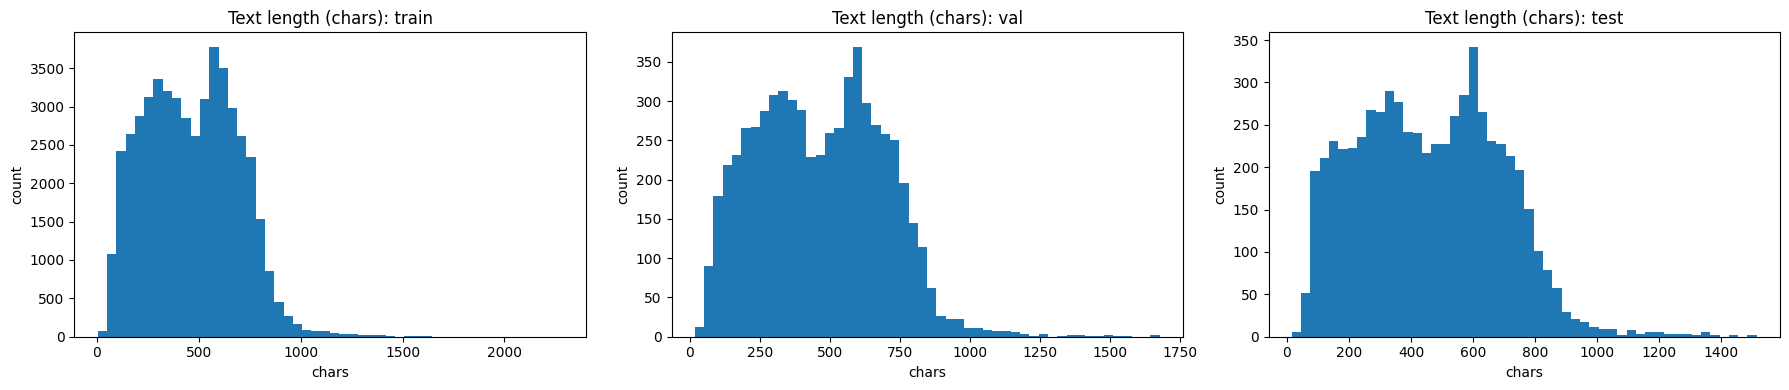

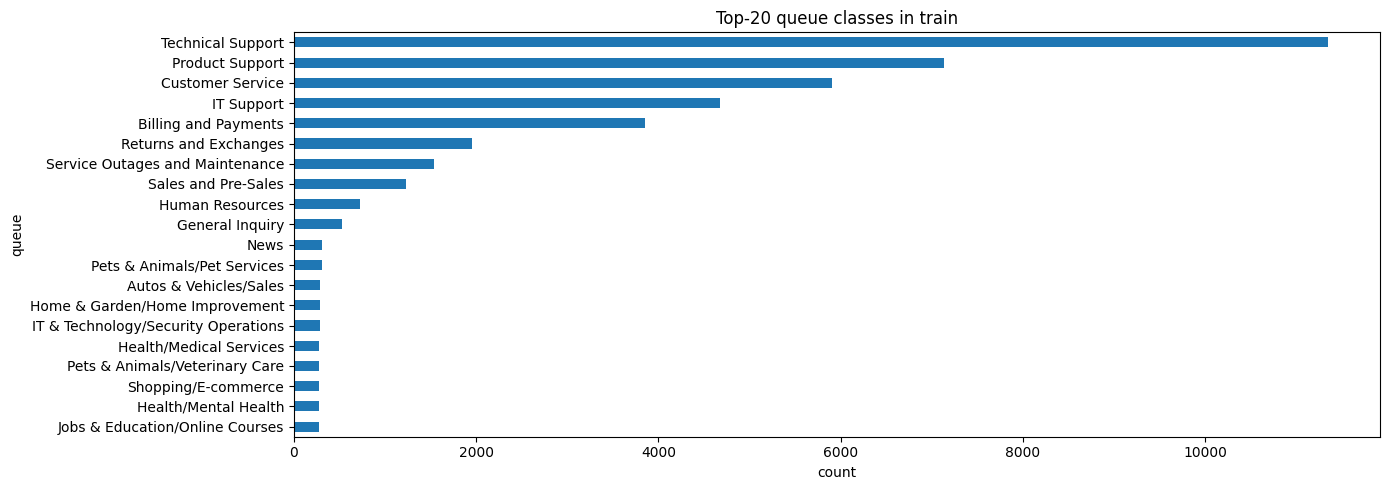

In [6]:
# =========================
# BASIC EDA
# =========================

print_header("MISSING VALUES")
for split_name, part in splits.items():
    miss = part[["subject", "body", "queue", "priority", "type", "language"]].isna().mean() * 100
    print(f"\n[{split_name}]")
    display(miss.round(3).rename("missing_%").to_frame())

print_header("TEXT LENGTH STATISTICS")
rows = []
for split_name, part in splits.items():
    text = part["full_text"]
    rows.append({
        "split": split_name,
        "chars_mean": text.str.len().mean(),
        "chars_p50": text.str.len().quantile(0.50),
        "chars_p90": text.str.len().quantile(0.90),
        "chars_p99": text.str.len().quantile(0.99),
        "words_mean": text.str.split().map(len).mean(),
        "words_p50": text.str.split().map(len).quantile(0.50),
        "words_p90": text.str.split().map(len).quantile(0.90),
        "words_p99": text.str.split().map(len).quantile(0.99),
    })
display(pd.DataFrame(rows).round(2))

print_header("CLASS COUNTS")
for target in ["queue", "priority", "type", "language"]:
    print(f"\nTarget: {target}")
    summary = []
    for split_name, part in splits.items():
        summary.append({
            "split": split_name,
            "n_classes": part[target].astype(str).nunique(),
            "top_class": part[target].astype(str).value_counts().index[0],
            "top_class_count": int(part[target].astype(str).value_counts().iloc[0]),
        })
    display(pd.DataFrame(summary))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, split_name in zip(axes, ["train", "val", "test"]):
    text = splits[split_name]["full_text"]
    ax.hist(text.str.len(), bins=50)
    ax.set_title(f"Text length (chars): {split_name}")
    ax.set_xlabel("chars")
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
train_df["queue"].astype(str).value_counts().head(20).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top-20 queue classes in train")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()

In [7]:
# =========================
# DUPLICATE CHECKS
# =========================

def duplicate_checks(splits: dict[str, pd.DataFrame]) -> None:
    rows = []
    hash_sets = {}

    for split_name, part in splits.items():
        hashes = part["full_text"].map(md5_text)
        unique_hashes = set(hashes.tolist())
        hash_sets[split_name] = unique_hashes
        rows.append({
            "split": split_name,
            "rows": len(part),
            "unique_texts": len(unique_hashes),
            "within_dup_rate": 1 - len(unique_hashes) / len(part)
        })

    print_header("WITHIN-SPLIT DUPLICATES")
    display(pd.DataFrame(rows).round(6))

    inter = {
        "train∩val": len(hash_sets["train"] & hash_sets["val"]),
        "train∩test": len(hash_sets["train"] & hash_sets["test"]),
        "val∩test": len(hash_sets["val"] & hash_sets["test"]),
    }

    print_header("CROSS-SPLIT DUPLICATES")
    display(pd.DataFrame([inter]))
    if sum(inter.values()) == 0:
        print("OK: cross-split duplicate texts were not found.")
    else:
        print("WARNING: cross-split duplicate texts were found.")

duplicate_checks(splits)


WITHIN-SPLIT DUPLICATES


,split,rows,unique_texts,within_dup_rate
0,train,49412,42749,0.134846
1,val,6176,5362,0.131801
2,test,6177,5348,0.134208



CROSS-SPLIT DUPLICATES


,train∩val,train∩test,val∩test
0,0,0,0


OK: cross-split duplicate texts were not found.


In [8]:
# =========================
# BUILD FEATURE SPACES
# =========================

def build_feature_spaces(train_df, val_df, test_df):
    spaces = {}

    # 1) Word TF-IDF по полному тексту
    vec_word_full = TfidfVectorizer(
        max_features=WORD_FULL_MAX_FEATURES,
        ngram_range=(1, 2),
        min_df=2,
        lowercase=True,
        strip_accents="unicode",
        sublinear_tf=True,
    )
    vec_word_full.fit(train_df["full_text"])
    spaces["word_full"] = {
        "train": vec_word_full.transform(train_df["full_text"]),
        "val": vec_word_full.transform(val_df["full_text"]),
        "test": vec_word_full.transform(test_df["full_text"]),
    }

    # 2) Char TF-IDF по полному тексту
    vec_char_full = TfidfVectorizer(
        max_features=CHAR_FULL_MAX_FEATURES,
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        lowercase=True,
        sublinear_tf=True,
    )
    vec_char_full.fit(train_df["full_text"])
    spaces["char_full"] = {
        "train": vec_char_full.transform(train_df["full_text"]),
        "val": vec_char_full.transform(val_df["full_text"]),
        "test": vec_char_full.transform(test_df["full_text"]),
    }

    # 3) Word TF-IDF по subject
    vec_subject_word = TfidfVectorizer(
        max_features=SUBJECT_WORD_MAX_FEATURES,
        ngram_range=(1, 2),
        min_df=2,
        lowercase=True,
        strip_accents="unicode",
        sublinear_tf=True,
    )
    vec_subject_word.fit(train_df["subject_text"])
    spaces["subject_word"] = {
        "train": vec_subject_word.transform(train_df["subject_text"]),
        "val": vec_subject_word.transform(val_df["subject_text"]),
        "test": vec_subject_word.transform(test_df["subject_text"]),
    }

    # 4) language one-hot
    ohe = safe_one_hot_encoder()
    lang_train = train_df[["language"]].fillna("NA").astype(str)
    lang_val = val_df[["language"]].fillna("NA").astype(str)
    lang_test = test_df[["language"]].fillna("NA").astype(str)
    ohe.fit(lang_train)
    spaces["lang"] = {
        "train": ohe.transform(lang_train),
        "val": ohe.transform(lang_val),
        "test": ohe.transform(lang_test),
    }

    return spaces


BASE_SPACES = build_feature_spaces(train_df, val_df, test_df)

FEATURE_SETS = {
    "wf": ["word_full"],
    "wf_cf": ["word_full", "char_full"],
    "wf_subj_lang": ["word_full", "subject_word", "lang"],
    "wf_cf_subj_lang": ["word_full", "char_full", "subject_word", "lang"],
}

def build_feature_set_matrices(base_spaces, feature_sets):
    matrices = {}
    for fs_name, parts in feature_sets.items():
        matrices[fs_name] = {}
        for split_name in ["train", "val", "test"]:
            matrices[fs_name][split_name] = hstack(
                [base_spaces[p][split_name] for p in parts],
                format="csr"
            )
    return matrices

FEATURE_MATRICES = build_feature_set_matrices(BASE_SPACES, FEATURE_SETS)

print_header("FEATURE SPACE SHAPES")
shape_rows = []
for fs_name in FEATURE_SETS:
    shape_rows.append({
        "feature_set": fs_name,
        "train_shape": FEATURE_MATRICES[fs_name]["train"].shape,
        "val_shape": FEATURE_MATRICES[fs_name]["val"].shape,
        "test_shape": FEATURE_MATRICES[fs_name]["test"].shape,
    })
display(pd.DataFrame(shape_rows))


FEATURE SPACE SHAPES


,feature_set,train_shape,val_shape,test_shape
0,wf,"(49412, 205516)","(6176, 205516)","(6177, 205516)"
1,wf_cf,"(49412, 314743)","(6176, 314743)","(6177, 314743)"
2,wf_subj_lang,"(49412, 235306)","(6176, 235306)","(6177, 235306)"
3,wf_cf_subj_lang,"(49412, 344533)","(6176, 344533)","(6177, 344533)"


In [9]:
# =========================
# MODEL CANDIDATES
# =========================

QUEUE_CANDIDATES = [
    {
        "name": "queue_svc_wf_cf",
        "feature_set": "wf_cf",
        "estimator": LinearSVC(C=0.9, class_weight="balanced"),
    },
    {
        "name": "queue_sgd_wf_cf_subj_lang",
        "feature_set": "wf_cf_subj_lang",
        "estimator": SGDClassifier(
            loss="log_loss",
            alpha=2e-6,
            penalty="l2",
            max_iter=40,
            tol=1e-3,
            random_state=SEED,
            class_weight="balanced",
        ),
    },
    {
        "name": "queue_cnb_wf",
        "feature_set": "wf",
        "estimator": ComplementNB(alpha=0.25),
    },
]

PRIORITY_CANDIDATES = [
    {
        "name": "priority_lr_wf_subj_lang",
        "feature_set": "wf_subj_lang",
        "estimator": LogisticRegression(
            C=4.0,
            max_iter=2500,
            solver="lbfgs",
            multi_class="auto",
        ),
    },
    {
        "name": "priority_sgd_wf_cf",
        "feature_set": "wf_cf",
        "estimator": SGDClassifier(
            loss="log_loss",
            alpha=5e-6,
            penalty="l2",
            max_iter=40,
            tol=1e-3,
            random_state=SEED,
        ),
    },
    {
        "name": "priority_cnb_wf",
        "feature_set": "wf",
        "estimator": ComplementNB(alpha=0.4),
    },
]

TYPE_CANDIDATES = [
    {
        "name": "type_lr_wf_subj_lang",
        "feature_set": "wf_subj_lang",
        "estimator": LogisticRegression(
            C=4.0,
            max_iter=2500,
            solver="lbfgs",
            multi_class="auto",
        ),
    },
    {
        "name": "type_sgd_wf_cf_subj_lang",
        "feature_set": "wf_cf_subj_lang",
        "estimator": SGDClassifier(
            loss="log_loss",
            alpha=4e-6,
            penalty="l2",
            max_iter=40,
            tol=1e-3,
            random_state=SEED,
        ),
    },
    {
        "name": "type_cnb_wf",
        "feature_set": "wf",
        "estimator": ComplementNB(alpha=0.3),
    },
]

In [10]:
# =========================
# TRAIN / SELECT / ENSEMBLE
# =========================

def train_target_candidates(
    target: str,
    candidates: list[dict],
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_matrices: dict[str, dict[str, csr_matrix]],
):
    y_train = train_df[target].astype(str).values
    y_val = val_df[target].astype(str).values
    y_test = test_df[target].astype(str).values

    class_order = np.sort(pd.Series(y_train).astype(str).unique())

    candidate_runs = []

    print_header(f"TRAINING CANDIDATES — {target}")

    for spec in candidates:
        model = clone(spec["estimator"])
        fs_name = spec["feature_set"]

        X_train = feature_matrices[fs_name]["train"]
        X_val = feature_matrices[fs_name]["val"]
        X_test = feature_matrices[fs_name]["test"]

        started = time.time()
        model.fit(X_train, y_train)
        fit_seconds = time.time() - started

        val_proba = align_proba_to_classes(model, X_val, class_order)
        test_proba = align_proba_to_classes(model, X_test, class_order)

        val_pred = predict_from_proba(class_order, val_proba)
        test_pred = predict_from_proba(class_order, test_proba)

        val_metric = metric_for_target(target, y_val, val_pred)
        test_metric = metric_for_target(target, y_test, test_pred)

        row = {
            "candidate": spec["name"],
            "feature_set": fs_name,
            "metric_name": metric_name_for_target(target),
            "val_metric": val_metric,
            "test_metric": test_metric,
            "fit_seconds": fit_seconds,
            "model": model,
            "val_proba": val_proba,
            "test_proba": test_proba,
            "val_pred": val_pred,
            "test_pred": test_pred,
        }
        candidate_runs.append(row)

    report = pd.DataFrame([
        {
            "candidate": r["candidate"],
            "feature_set": r["feature_set"],
            "metric_name": r["metric_name"],
            "val_metric": r["val_metric"],
            "test_metric": r["test_metric"],
            "fit_seconds": r["fit_seconds"],
        }
        for r in candidate_runs
    ]).sort_values("val_metric", ascending=False).reset_index(drop=True)

    display(report.round(4))

    # Лучший single model по val
    sorted_runs = sorted(candidate_runs, key=lambda x: x["val_metric"], reverse=True)
    best_single = sorted_runs[0]

    # Кандидаты ансамблей: top-2 и top-3
    ensemble_variants = []
    for k in [2, 3]:
        if len(sorted_runs) >= k:
            selected = sorted_runs[:k]
            weights = [max(r["val_metric"], 1e-8) for r in selected]
            val_blend = blend_probas([r["val_proba"] for r in selected], weights)
            test_blend = blend_probas([r["test_proba"] for r in selected], weights)

            val_pred = predict_from_proba(class_order, val_blend)
            test_pred = predict_from_proba(class_order, test_blend)

            ensemble_variants.append({
                "name": f"ensemble_top{k}",
                "k": k,
                "weights": weights,
                "members": [r["candidate"] for r in selected],
                "val_metric": metric_for_target(target, y_val, val_pred),
                "test_metric": metric_for_target(target, y_test, test_pred),
                "val_proba": val_blend,
                "test_proba": test_blend,
                "val_pred": val_pred,
                "test_pred": test_pred,
            })

    if ensemble_variants:
        ens_report = pd.DataFrame([
            {
                "candidate": r["name"],
                "members": " | ".join(r["members"]),
                "val_metric": r["val_metric"],
                "test_metric": r["test_metric"],
            }
            for r in ensemble_variants
        ]).sort_values("val_metric", ascending=False).reset_index(drop=True)

        print_header(f"ENSEMBLE CHECK — {target}")
        display(ens_report.round(4))

        best_ensemble = max(ensemble_variants, key=lambda x: x["val_metric"])
    else:
        best_ensemble = None

    use_ensemble = best_ensemble is not None and best_ensemble["val_metric"] > best_single["val_metric"]

    if use_ensemble:
        chosen = {
            "target": target,
            "mode": "ensemble",
            "class_order": class_order,
            "selected_name": best_ensemble["name"],
            "members": best_ensemble["members"],
            "val_metric": best_ensemble["val_metric"],
            "test_metric": best_ensemble["test_metric"],
            "val_proba": best_ensemble["val_proba"],
            "test_proba": best_ensemble["test_proba"],
            "val_pred": best_ensemble["val_pred"],
            "test_pred": best_ensemble["test_pred"],
            "candidate_report": report,
        }
    else:
        chosen = {
            "target": target,
            "mode": "single",
            "class_order": class_order,
            "selected_name": best_single["candidate"],
            "members": [best_single["candidate"]],
            "val_metric": best_single["val_metric"],
            "test_metric": best_single["test_metric"],
            "val_proba": best_single["val_proba"],
            "test_proba": best_single["test_proba"],
            "val_pred": best_single["val_pred"],
            "test_pred": best_single["test_pred"],
            "candidate_report": report,
        }

    print_header(f"SELECTED MODEL — {target}")
    display(pd.DataFrame([{
        "target": target,
        "mode": chosen["mode"],
        "selected_name": chosen["selected_name"],
        "members": " | ".join(chosen["members"]),
        "val_metric": chosen["val_metric"],
        "test_metric": chosen["test_metric"],
    }]).round(4))

    return chosen


queue_result = train_target_candidates(
    target="queue",
    candidates=QUEUE_CANDIDATES,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    feature_matrices=FEATURE_MATRICES,
)

priority_result = train_target_candidates(
    target="priority",
    candidates=PRIORITY_CANDIDATES,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    feature_matrices=FEATURE_MATRICES,
)

type_result = train_target_candidates(
    target="type",
    candidates=TYPE_CANDIDATES,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    feature_matrices=FEATURE_MATRICES,
)


TRAINING CANDIDATES — queue


,candidate,feature_set,metric_name,val_metric,test_metric,fit_seconds
0,queue_sgd_wf_cf_subj_lang,wf_cf_subj_lang,macro_f1,0.8971,0.8960,94.6016
1,queue_svc_wf_cf,wf_cf,macro_f1,0.8964,0.8967,109.5994
2,queue_cnb_wf,wf,macro_f1,0.8363,0.8369,1.1185



ENSEMBLE CHECK — queue


,candidate,members,val_metric,test_metric
0,ensemble_top3,queue_sgd_wf_cf_subj_lang | queue_svc_wf_cf | queue_cnb_wf,0.8982,0.8978
1,ensemble_top2,queue_sgd_wf_cf_subj_lang | queue_svc_wf_cf,0.8976,0.8960



SELECTED MODEL — queue


...

,candidate,feature_set,metric_name,val_metric,test_metric,fit_seconds
0,type_sgd_wf_cf_subj_lang,wf_cf_subj_lang,accuracy,0.8884,0.8891,9.1318
1,type_lr_wf_subj_lang,wf_subj_lang,accuracy,0.8881,0.8894,74.9321
2,type_cnb_wf,wf,accuracy,0.7821,0.7805,0.1946



ENSEMBLE CHECK — type


,candidate,members,val_metric,test_metric
0,ensemble_top2,type_sgd_wf_cf_subj_lang | type_lr_wf_subj_lang,0.8910,0.8915
1,ensemble_top3,type_sgd_wf_cf_subj_lang | type_lr_wf_subj_lang | type_cnb_wf,0.8889,0.8896



SELECTED MODEL — type


,target,mode,selected_name,members,val_metric,test_metric
0,type,ensemble,ensemble_top2,type_sgd_wf_cf_subj_lang | type_lr_wf_subj_lang,0.891,0.8915


In [11]:
# =========================
# FINAL METRICS
# =========================

val_metrics = eval_metrics_all(
    yq_true=val_df["queue"].astype(str).values,
    yq_pred=queue_result["val_pred"],
    yp_true=val_df["priority"].astype(str).values,
    yp_pred=priority_result["val_pred"],
    yt_true=val_df["type"].astype(str).values,
    yt_pred=type_result["val_pred"],
)

test_metrics = eval_metrics_all(
    yq_true=test_df["queue"].astype(str).values,
    yq_pred=queue_result["test_pred"],
    yp_true=test_df["priority"].astype(str).values,
    yp_pred=priority_result["test_pred"],
    yt_true=test_df["type"].astype(str).values,
    yt_pred=type_result["test_pred"],
)

print_header("VALIDATION METRICS")
display(pd.DataFrame([val_metrics]).round(4))

print_header("TEST METRICS")
display(pd.DataFrame([test_metrics]).round(4))

print_header("SELECTED PIPELINE SUMMARY")
display(pd.DataFrame([
    {
        "target": "queue",
        "mode": queue_result["mode"],
        "selected": queue_result["selected_name"],
        "members": " | ".join(queue_result["members"]),
    },
    {
        "target": "priority",
        "mode": priority_result["mode"],
        "selected": priority_result["selected_name"],
        "members": " | ".join(priority_result["members"]),
    },
    {
        "target": "type",
        "mode": type_result["mode"],
        "selected": type_result["selected_name"],
        "members": " | ".join(type_result["members"]),
    },
]))


VALIDATION METRICS


,queue_macro_f1,queue_acc,priority_acc,type_acc,final_score
0,0.8982,0.6627,0.7092,0.891,0.8688



TEST METRICS


,queue_macro_f1,queue_acc,priority_acc,type_acc,final_score
0,0.8978,0.6587,0.7037,0.8915,0.8677



SELECTED PIPELINE SUMMARY


,target,mode,selected,members
0,queue,ensemble,ensemble_top3,queue_sgd_wf_cf_subj_lang | queue_svc_wf_cf | queue_cnb_wf
1,priority,ensemble,ensemble_top3,priority_sgd_wf_cf | priority_lr_wf_subj_lang | priority_cnb_wf
2,type,ensemble,ensemble_top2,type_sgd_wf_cf_subj_lang | type_lr_wf_subj_lang


In [12]:
# =========================
# QUEUE REPORT
# =========================

print_header("QUEUE — TEST CLASSIFICATION REPORT")
print(classification_report(
    test_df["queue"].astype(str).values,
    queue_result["test_pred"],
    digits=4,
    zero_division=0
))


QUEUE — TEST CLASSIFICATION REPORT
                                        precision    recall  f1-score   support

           Arts & Entertainment/Movies     1.0000    0.9231    0.9600        26
            Arts & Entertainment/Music     0.9231    1.0000    0.9600        24
          Autos & Vehicles/Maintenance     0.9615    0.9615    0.9615        26
                Autos & Vehicles/Sales     0.9500    1.0000    0.9744        38
            Beauty & Fitness/Cosmetics     1.0000    0.9583    0.9787        24
     Beauty & Fitness/Fitness Training     0.9630    1.0000    0.9811        26
                  Billing and Payments     0.8323    0.7744    0.8023       532
            Books & Literature/Fiction     1.0000    0.9286    0.9630        28
        Books & Literature/Non-Fiction     1.0000    0.9722    0.9859        36
   Business & Industrial/Manufacturing     1.0000    1.0000    1.0000        33
                      Customer Service     0.4875    0.5091    0.4981       766
   

In [13]:
# =========================
# CONFIDENCE / COVERAGE ANALYSIS
# =========================

# Используем confidence из итоговой blended probability по каждой задаче.
# Для общей уверенности берём взвешенное среднее с теми же весами, что и в Final Score:
#   0.70 * conf(queue) + 0.15 * conf(priority) + 0.15 * conf(type)

queue_conf_test = queue_result["test_proba"].max(axis=1)
priority_conf_test = priority_result["test_proba"].max(axis=1)
type_conf_test = type_result["test_proba"].max(axis=1)

joint_conf_test = (
    0.70 * queue_conf_test +
    0.15 * priority_conf_test +
    0.15 * type_conf_test
)

order = np.argsort(-joint_conf_test)

rows = []
n = len(test_df)

yq_true = test_df["queue"].astype(str).values
yp_true = test_df["priority"].astype(str).values
yt_true = test_df["type"].astype(str).values

yq_pred = queue_result["test_pred"]
yp_pred = priority_result["test_pred"]
yt_pred = type_result["test_pred"]

for cov in COVERAGES:
    k = max(1, int(round(n * cov)))
    idx = order[:k]

    metrics = eval_metrics_all(
        yq_true=yq_true[idx], yq_pred=yq_pred[idx],
        yp_true=yp_true[idx], yp_pred=yp_pred[idx],
        yt_true=yt_true[idx], yt_pred=yt_pred[idx]
    )

    rows.append({
        "coverage": cov,
        "n_samples": k,
        "manual_review_share": 1 - cov,
        "avg_joint_confidence": float(joint_conf_test[idx].mean()),
        **metrics,
    })

confidence_table = pd.DataFrame(rows)

print_header("CONFIDENCE / COVERAGE TABLE")
display(confidence_table.round(4))

best_operating_point = confidence_table.sort_values(
    ["final_score", "queue_macro_f1", "queue_acc"],
    ascending=False
).iloc[0]

print_header("BEST OPERATING POINT")
display(pd.DataFrame([best_operating_point]).round(4))


CONFIDENCE / COVERAGE TABLE


,coverage,n_samples,manual_review_share,avg_joint_confidence,queue_macro_f1,queue_acc,priority_acc,type_acc,final_score
0,0.5,3088,0.5,0.5039,0.9561,0.8931,0.8381,0.9553,0.9382
1,0.6,3706,0.4,0.4832,0.9422,0.8392,0.8073,0.9450,0.9224
2,0.7,4324,0.3,0.4648,0.9280,0.7902,0.7810,0.9364,0.9072
3,0.8,4942,0.2,0.4483,0.9164,0.7382,0.7539,0.9259,0.8934
4,0.9,5559,0.1,0.4329,0.9070,0.6974,0.7296,0.9149,0.8816
5,1.0,6177,0.0,0.4169,0.8978,0.6587,0.7037,0.8915,0.8677



BEST OPERATING POINT


,coverage,n_samples,manual_review_share,avg_joint_confidence,queue_macro_f1,queue_acc,priority_acc,type_acc,final_score
0,0.5,3088.0,0.5,0.5039,0.9561,0.8931,0.8381,0.9553,0.9382


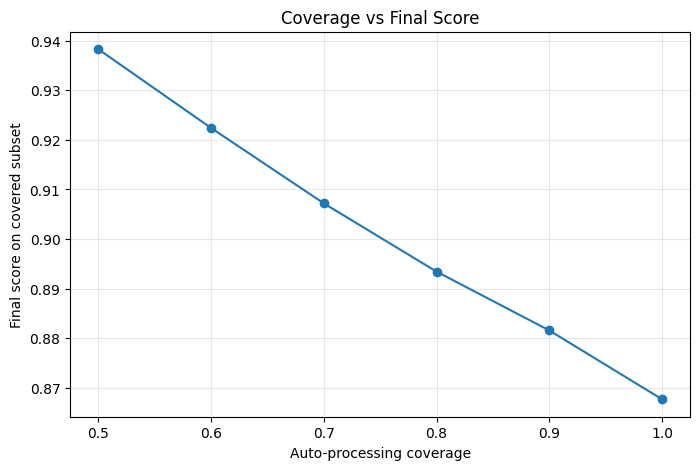

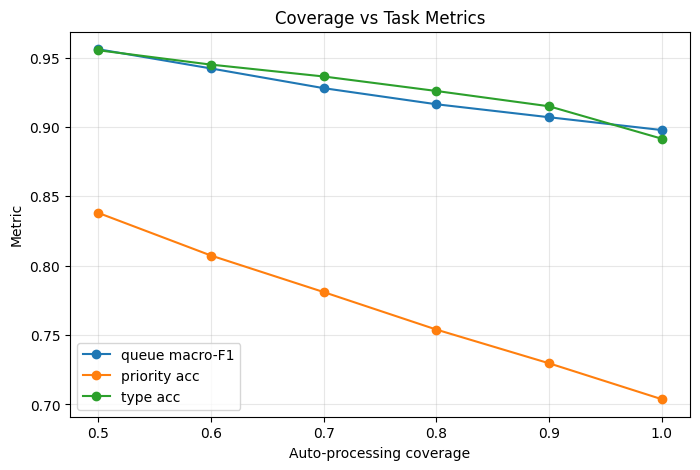

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(confidence_table["coverage"], confidence_table["final_score"], marker="o")
ax.set_title("Coverage vs Final Score")
ax.set_xlabel("Auto-processing coverage")
ax.set_ylabel("Final score on covered subset")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(confidence_table["coverage"], confidence_table["queue_macro_f1"], marker="o", label="queue macro-F1")
ax.plot(confidence_table["coverage"], confidence_table["priority_acc"], marker="o", label="priority acc")
ax.plot(confidence_table["coverage"], confidence_table["type_acc"], marker="o", label="type acc")
ax.set_title("Coverage vs Task Metrics")
ax.set_xlabel("Auto-processing coverage")
ax.set_ylabel("Metric")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [15]:
# =========================
# OPTIONAL: MULTITASK TRANSFORMER
# =========================

if not RUN_TRANSFORMER:
    print("RUN_TRANSFORMER = False -> transformer block skipped.")

RUN_TRANSFORMER = False -> transformer block skipped.


In [16]:
if RUN_TRANSFORMER:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset

    from transformers import (
        AutoTokenizer,
        AutoModel,
        Trainer,
        TrainingArguments,
        DataCollatorWithPadding,
    )

    print_header("TRANSFORMER SETUP")
    print("Model:", TRANSFORMER_MODEL_NAME)
    print("CUDA:", torch.cuda.is_available())

    class SimpleLabelEncoder:
        def __init__(self):
            self.classes_ = None
            self.class_to_id = None
            self.id_to_class = None

        def fit(self, y):
            self.classes_ = sorted(pd.Series(y).astype(str).unique().tolist())
            self.class_to_id = {c: i for i, c in enumerate(self.classes_)}
            self.id_to_class = {i: c for c, i in self.class_to_id.items()}
            return self

        def transform(self, y):
            return np.array([self.class_to_id[str(v)] for v in y], dtype=np.int64)

        def inverse_transform(self, y):
            return np.array([self.id_to_class[int(v)] for v in y], dtype=object)

    encoders = {}
    for target in ["queue", "priority", "type"]:
        encoders[target] = SimpleLabelEncoder().fit(train_df[target].astype(str))

    tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)

    class TicketDataset(Dataset):
        def __init__(self, df, tokenizer, encoders, max_length=256):
            self.texts = df["full_text"].tolist()
            self.queue = encoders["queue"].transform(df["queue"].astype(str))
            self.priority = encoders["priority"].transform(df["priority"].astype(str))
            self.type_ = encoders["type"].transform(df["type"].astype(str))
            self.tokenizer = tokenizer
            self.max_length = max_length

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            enc = self.tokenizer(
                self.texts[idx],
                truncation=True,
                max_length=self.max_length,
                padding=False,
            )
            item = {k: torch.tensor(v, dtype=torch.long) for k, v in enc.items()}
            item["labels_queue"] = torch.tensor(self.queue[idx], dtype=torch.long)
            item["labels_priority"] = torch.tensor(self.priority[idx], dtype=torch.long)
            item["labels_type"] = torch.tensor(self.type_[idx], dtype=torch.long)
            return item

    train_ds = TicketDataset(train_df, tokenizer, encoders, max_length=MAX_LENGTH)
    val_ds = TicketDataset(val_df, tokenizer, encoders, max_length=MAX_LENGTH)
    test_ds = TicketDataset(test_df, tokenizer, encoders, max_length=MAX_LENGTH)

    class MultiTaskModel(nn.Module):
        def __init__(self, model_name, n_queue, n_priority, n_type,
                     queue_weight=2.0, priority_weight=1.0, type_weight=1.0):
            super().__init__()
            self.encoder = AutoModel.from_pretrained(model_name)
            hidden = self.encoder.config.hidden_size
            self.dropout = nn.Dropout(0.1)
            self.queue_head = nn.Linear(hidden, n_queue)
            self.priority_head = nn.Linear(hidden, n_priority)
            self.type_head = nn.Linear(hidden, n_type)

            self.queue_loss = nn.CrossEntropyLoss()
            self.priority_loss = nn.CrossEntropyLoss()
            self.type_loss = nn.CrossEntropyLoss()

            self.queue_weight = queue_weight
            self.priority_weight = priority_weight
            self.type_weight = type_weight

        def forward(self, input_ids=None, attention_mask=None,
                    labels_queue=None, labels_priority=None, labels_type=None, **kwargs):
            outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask, **kwargs)
            pooled = outputs.last_hidden_state[:, 0]
            pooled = self.dropout(pooled)

            logits_queue = self.queue_head(pooled)
            logits_priority = self.priority_head(pooled)
            logits_type = self.type_head(pooled)

            loss = None
            if labels_queue is not None:
                lq = self.queue_loss(logits_queue, labels_queue)
                lp = self.priority_loss(logits_priority, labels_priority)
                lt = self.type_loss(logits_type, labels_type)
                loss = self.queue_weight * lq + self.priority_weight * lp + self.type_weight * lt

            return {
                "loss": loss,
                "logits_queue": logits_queue,
                "logits_priority": logits_priority,
                "logits_type": logits_type,
            }

    class MultiTaskCollator:
        def __init__(self, tokenizer):
            self.base = DataCollatorWithPadding(tokenizer=tokenizer)

        def __call__(self, features):
            labels_queue = torch.tensor([f.pop("labels_queue") for f in features], dtype=torch.long)
            labels_priority = torch.tensor([f.pop("labels_priority") for f in features], dtype=torch.long)
            labels_type = torch.tensor([f.pop("labels_type") for f in features], dtype=torch.long)

            batch = self.base(features)
            batch["labels_queue"] = labels_queue
            batch["labels_priority"] = labels_priority
            batch["labels_type"] = labels_type
            return batch

    def compute_metrics_multitask(pred_obj):
        preds = pred_obj.predictions
        if isinstance(preds, tuple):
            logits_q, logits_p, logits_t = preds
        else:
            logits_q = preds["logits_queue"]
            logits_p = preds["logits_priority"]
            logits_t = preds["logits_type"]

        labels = pred_obj.label_ids
        if isinstance(labels, tuple):
            yq, yp, yt = labels
        else:
            yq = labels["labels_queue"]
            yp = labels["labels_priority"]
            yt = labels["labels_type"]

        pq = logits_q.argmax(axis=1)
        pp = logits_p.argmax(axis=1)
        pt = logits_t.argmax(axis=1)

        queue_macro_f1 = f1_score(yq, pq, average="macro")
        queue_acc = accuracy_score(yq, pq)
        priority_acc = accuracy_score(yp, pp)
        type_acc = accuracy_score(yt, pt)
        final_score = compute_final_score(queue_macro_f1, priority_acc, type_acc)

        return {
            "queue_macro_f1": queue_macro_f1,
            "queue_acc": queue_acc,
            "priority_acc": priority_acc,
            "type_acc": type_acc,
            "final_score": final_score,
        }

    model = MultiTaskModel(
        model_name=TRANSFORMER_MODEL_NAME,
        n_queue=len(encoders["queue"].classes_),
        n_priority=len(encoders["priority"].classes_),
        n_type=len(encoders["type"].classes_),
        queue_weight=QUEUE_LOSS_WEIGHT,
        priority_weight=PRIORITY_LOSS_WEIGHT,
        type_weight=TYPE_LOSS_WEIGHT,
    )

    training_args = TrainingArguments(
        output_dir="./transformer_multitask_runs",
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_steps=100,
        logging_strategy="steps",
        load_best_model_at_end=True,
        metric_for_best_model="final_score",
        greater_is_better=True,
        report_to="none",
        seed=SEED,
        fp16=torch.cuda.is_available(),
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        data_collator=MultiTaskCollator(tokenizer),
        compute_metrics=compute_metrics_multitask,
    )

    trainer.train()

    print_header("TRANSFORMER VALIDATION")
    val_transformer_metrics = trainer.evaluate(eval_dataset=val_ds)
    print(val_transformer_metrics)

    print_header("TRANSFORMER TEST")
    test_transformer_metrics = trainer.evaluate(eval_dataset=test_ds)
    print(test_transformer_metrics)

In [17]:
# =========================
# FINAL SUMMARY
# =========================

print_header("FINAL CLASSICAL RESULT")
print(f"Queue Macro-F1 (test): {test_metrics['queue_macro_f1']:.4f}")
print(f"Queue Accuracy (test): {test_metrics['queue_acc']:.4f}")
print(f"Priority Accuracy (test): {test_metrics['priority_acc']:.4f}")
print(f"Type Accuracy (test): {test_metrics['type_acc']:.4f}")
print(f"Final Score (test): {test_metrics['final_score']:.4f}")

print_header("BEST CONFIDENCE OPERATING POINT")
display(pd.DataFrame([best_operating_point]).round(4))


FINAL CLASSICAL RESULT
Queue Macro-F1 (test): 0.8978
Queue Accuracy (test): 0.6587
Priority Accuracy (test): 0.7037
Type Accuracy (test): 0.8915
Final Score (test): 0.8677

BEST CONFIDENCE OPERATING POINT


,coverage,n_samples,manual_review_share,avg_joint_confidence,queue_macro_f1,queue_acc,priority_acc,type_acc,final_score
0,0.5,3088.0,0.5,0.5039,0.9561,0.8931,0.8381,0.9553,0.9382
